<a href="https://colab.research.google.com/github/NipunRaj96/Customer-Churn-Prediction/blob/main/ChurnPrediction_Using_ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import os

In [ ]:
df = pd.read_csv('/content/Churn_Modelling.csv')

In [ ]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
df.info() #check if theres any missing value in any column

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [ ]:
df.duplicated().sum() #check if theres any duplicate value

np.int64(0)

In [ ]:
df['Exited'].value_counts() #how many left and how many are still there

,count
Exited,
0,7963
1,2037


In [ ]:
df['Geography'].value_counts()

,count
Geography,
France,5014
Germany,2509
Spain,2477


In [ ]:
df.drop(columns=['RowNumber','CustomerId','Surname'], inplace=True) #inplace=True: This is a crucial argument.
# Setting it to True means that the DataFrame df is directly modified. The columns are dropped in place, without creating a new copy
# of the DataFrame. If it was set to False (which is the default), a new DataFrame with the columns removed would be returned, and
# the original df would remain unchanged.

In [ ]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
df = pd.get_dummies(df,columns=['Geography','Gender'], drop_first=True)

In [ ]:
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


In [ ]:
df['Geography_Germany'] = df['Geography_Germany'].astype(int)
df['Geography_Spain'] = df['Geography_Spain'].astype(int)
df['Gender_Male'] = df['Gender_Male'].astype(int)

In [ ]:
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1,0


In [ ]:
X=df.drop(columns=['Exited'])
y=df['Exited']
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=1)

In [ ]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train_scaled=sc.fit_transform(X_train)
X_test_scaled=sc.transform(X_test)

In [ ]:
X_train_scaled

array([[-0.23082038, -0.94449979, -0.70174202, ...,  1.71490137,
        -0.57273139,  0.91509065],
       [-0.25150912, -0.94449979, -0.35520275, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [-0.3963303 ,  0.77498705,  0.33787579, ...,  1.71490137,
        -0.57273139, -1.09278791],
       ...,
       [ 0.22433188,  0.58393295,  1.3774936 , ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 0.13123255,  0.01077067,  1.03095433, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 1.1656695 ,  0.29735181,  0.33787579, ...,  1.71490137,
        -0.57273139,  0.91509065]])

In [ ]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
model=Sequential()
model.add(Dense(11,activation='sigmoid',input_dim=11)) #hidden layer with 11 nodes and we using act.func. sigmoid with 11 input dimensions
model.add(Dense(11,activation='sigmoid')) #hidden layer 2 with 11 nodes and we using act.func. sigmoid
model.add(Dense(1,activation='sigmoid')) #output layer with 1 node that also uses the act.func. sigmoid

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary() #model architecture drawn in copy

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                      │ (None, 11)                  │             132 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 11)                  │             132 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 1)                   │              12 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(loss='binary_crossentropy',optimizer='Adam')

In [ ]:
history=model.fit(X_train_scaled,y_train,epochs=40,validation_split=0.2)

Epoch 1/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3288 - val_loss: 0.3486
Epoch 2/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.3409 - val_loss: 0.3476
Epoch 3/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.3379 - val_loss: 0.3467
Epoch 4/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3339 - val_loss: 0.3465
Epoch 5/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3393 - val_loss: 0.3462
Epoch 6/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3333 - val_loss: 0.3474
Epoch 7/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3402 - val_loss: 0.3471
Epoch 8/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3444 - val_loss: 0.3461
Epoch 9/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3370 - val_loss: 0.3454
Epoch 10/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3265 - val_loss: 0.3446
Epoch 11/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3291 - val_loss: 0.3441
Epoch 12/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

In [ ]:
model.layers[0].get_weights() # 33 weights and 3 biases for 1 layer

[array([[ 3.2109839e-01,  2.8324541e-01,  1.9170745e-01,  9.9078864e-02,
         -9.2190439e-03,  9.4720460e-02, -1.3692614e-01,  4.4861844e-01,
          3.4018484e-01,  2.2220360e-01,  8.4908731e-02],
        [-2.0707815e+00, -3.8089794e-01,  1.6460036e-01, -6.7632861e-02,
          1.7803041e+00,  3.9971659e-01,  8.8535261e-01, -4.2281184e-01,
          4.7586554e-01, -1.7318176e+00, -1.4743264e+00],
        [-5.0131166e-01,  3.6516911e-01, -1.7722763e-01,  7.4741639e-02,
         -3.7501040e-01,  2.7339393e-01,  5.3281549e-02,  7.0827138e-01,
          2.1468683e-01, -9.1005653e-02, -2.0799638e-01],
        [ 5.0707672e-02, -5.3603929e-01,  3.9553648e-01, -2.1919594e+00,
          2.9889041e-01, -7.8661984e-01,  5.7199603e-01, -5.8657771e-01,
          4.3447500e-01,  5.8873057e-01,  9.6219975e-01],
        [-4.2474803e-01,  8.6930674e-01,  1.0699216e+00, -1.7139301e+00,
          6.0333276e-01, -3.1830922e-01,  3.9698498e+00, -4.8520616e-01,
         -8.1061018e-01, -8.0938745e-0

In [ ]:
model.layers[1].get_weights() #3 weights and 1 bias(obv the output layer node)

[array([[ 1.0671206 ,  0.27995977, -0.9202412 , -0.53031236, -0.12090883,
          0.6918391 ,  0.6830704 ,  0.91343856, -0.34383795,  0.9616229 ,
          0.37480682],
        [-1.3996724 , -1.643279  ,  1.2555854 ,  1.4124258 ,  1.3823118 ,
         -1.4582492 , -1.4288627 ,  0.19942814,  1.3935627 , -1.349719  ,
         -1.1979156 ],
        [ 0.04719074, -0.56877005,  0.61801404,  1.1122328 , -0.03050687,
         -0.64940506,  0.29583958,  0.18150833, -0.23106721, -0.49150038,
          0.2739345 ],
        [ 0.40476575,  1.0772618 , -1.2609127 , -1.7603501 , -1.0316167 ,
          0.67070436,  0.5515253 , -0.22539242, -0.41885665,  0.6792613 ,
          0.34716812],
        [-0.9357941 , -1.1513038 ,  1.0917292 ,  0.96099085,  1.2912263 ,
         -0.7149579 , -1.1452332 ,  0.00395227,  1.110171  , -1.163368  ,
         -1.3553692 ],
        [ 0.45593238,  0.42068675, -0.74935716, -1.0809451 ,  0.16673505,
          0.3175371 , -0.13847946,  0.3003191 , -0.4353519 ,  0.7931097

In [ ]:
y_log = model.predict(X_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [ ]:
y_pred=np.where(y_log>0.5,1,0)#setting a threshold value if ylog is more than .5 customer will leave the bank else not

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.863

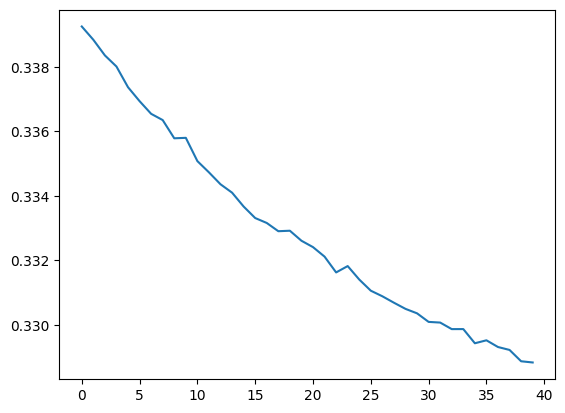

In [ ]:
plt.plot(history.history['loss']) #shows how our training error reduced while runnning from 0 to 40 epochs